In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

np.random.seed(42)

# Background
In the models we have built so far, all connections in the network are equally likely to transmit an innovation. In reality, individuals tend to interact more with people similar to themselves. This phenomenon is called called homophily. For example, people are more likely to adopt a behaviour if it comes from someone of the same age, social group, or cultural background.

In this exercise, you will run a modified version of the diffusion model that incorporates homophily, and interpret its effects.

# The code
Each node is assigned a group (0 or 1). Transmission between two nodes is modulated by a homophily parameter $h∈[0,1]$:

- h=0 : group identity has no effect, equivalent to the base model
- h=1 : transmission only occurs between members of the same group

In [2]:
def diffusion_homophily(G, p_t, h, r_max, sim=1):
    N      = G.number_of_nodes()
    adjm   = nx.to_numpy_array(G, dtype=bool)
    state  = np.zeros(N, dtype=int)
    state[np.random.randint(N)] = 1

    # Assign each node randomly to group 0 or group 1
    groups = np.random.randint(0, 2, size=N)

    rows = []
    for r in range(r_max):
        new_state = state.copy()
        for i in np.where(state == 1)[0]:
            neighbours = np.where(adjm[i])[0]
            for j in neighbours:
                if state[j] == 0:
                    # Reduce transmission probability across group boundaries
                    same_group  = groups[i] == groups[j]
                    p_effective = p_t if same_group else p_t * (1 - h)
                    if np.random.uniform() < p_effective:
                        new_state[j] = 1
        state = new_state
        rows.append({
            "time":       r + 1,
            "proportion": np.sum(state) / N,
            "group0":     np.sum((state == 1) & (groups == 0)) / np.sum(groups == 0),
            "group1":     np.sum((state == 1) & (groups == 1)) / np.sum(groups == 1),
            "h":          h,
            "sim":        sim
        })
    return pd.DataFrame(rows)

Run it with:

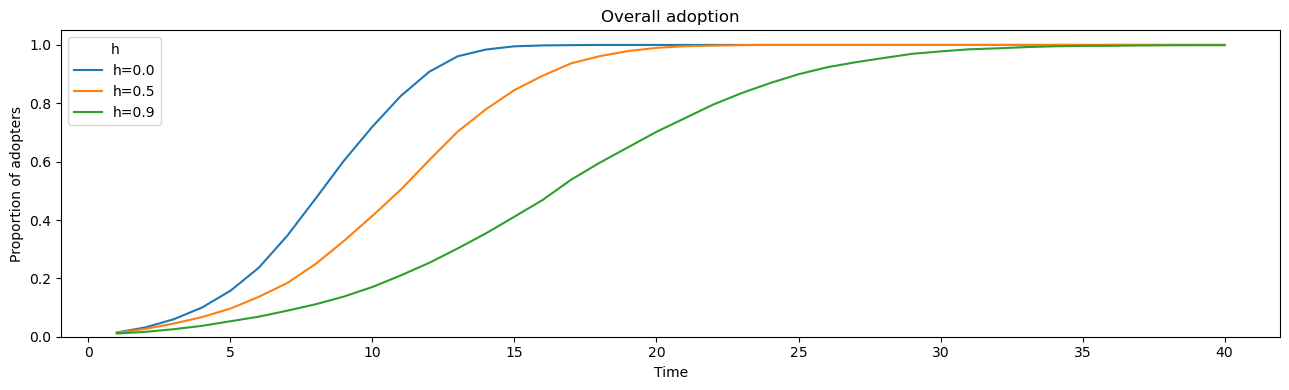

In [3]:
G      = nx.watts_strogatz_graph(n=200, k=6, p=0.1, seed=42)
h_vals = [0, 0.5, 0.9]
n_reps = 20

np.random.seed(7)
results = pd.concat([
    diffusion_homophily(G=G, p_t=0.3, h=h, r_max=40, sim=i).assign(h=h)
    for h in h_vals
    for i in range(n_reps)
], ignore_index=True)

mean_r = results.groupby(["h", "time"])["proportion"].mean().reset_index()

fig, axes = plt.subplots(figsize=(13, 4))

# Left: overall adoption by h
for h, grp in mean_r.groupby("h"):
    axes.plot(grp["time"], grp["proportion"], label=f"h={h}")
axes.set_ylim(0, 1.05)
axes.set_xlabel("Time")
axes.set_ylabel("Proportion of adopters")
axes.set_title("Overall adoption")
axes.legend(title="h")

plt.tight_layout()
plt.show()

# Questions (answer in your notebook)

## 1.

Select different values for *h* and run the model.

Explain why you chosed such value based on your experience.

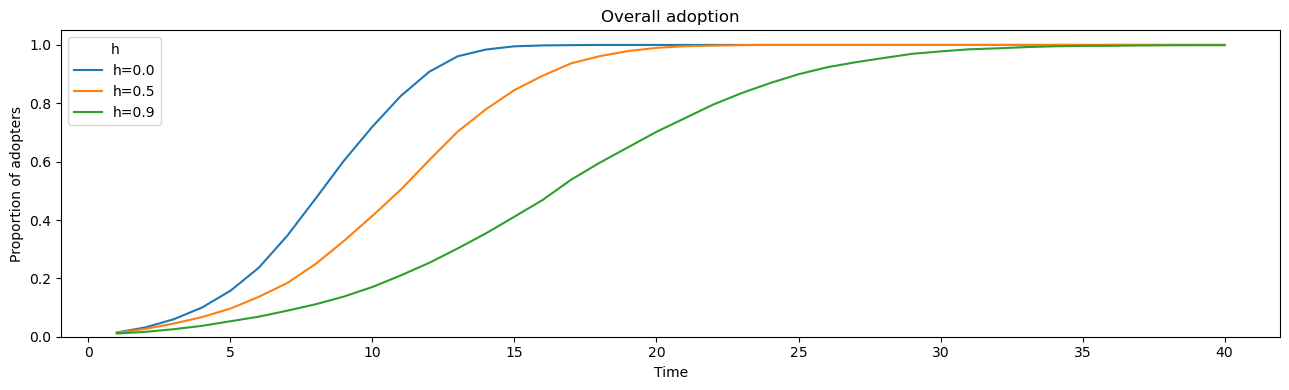

In [4]:
G      = nx.watts_strogatz_graph(n=200, k=6, p=0.1, seed=42)
h_vals = [0, 0.5, 0.9]
n_reps = 20

np.random.seed(7)
results = pd.concat([
    diffusion_homophily(G=G, p_t=0.3, h=h, r_max=40, sim=i).assign(h=h)
    for h in h_vals
    for i in range(n_reps)
], ignore_index=True)

mean_r = results.groupby(["h", "time"])["proportion"].mean().reset_index()

fig, axes = plt.subplots(figsize=(13, 4))

# Left: overall adoption by h
for h, grp in mean_r.groupby("h"):
    axes.plot(grp["time"], grp["proportion"], label=f"h={h}")
axes.set_ylim(0, 1.05)
axes.set_xlabel("Time")
axes.set_ylabel("Proportion of adopters")
axes.set_title("Overall adoption")
axes.legend(title="h")

plt.tight_layout()
plt.show()

## 2.

What is the effect of increasing *h* on overall speed and final level of adoptions ? Explain this mechanism in up to four sentences.

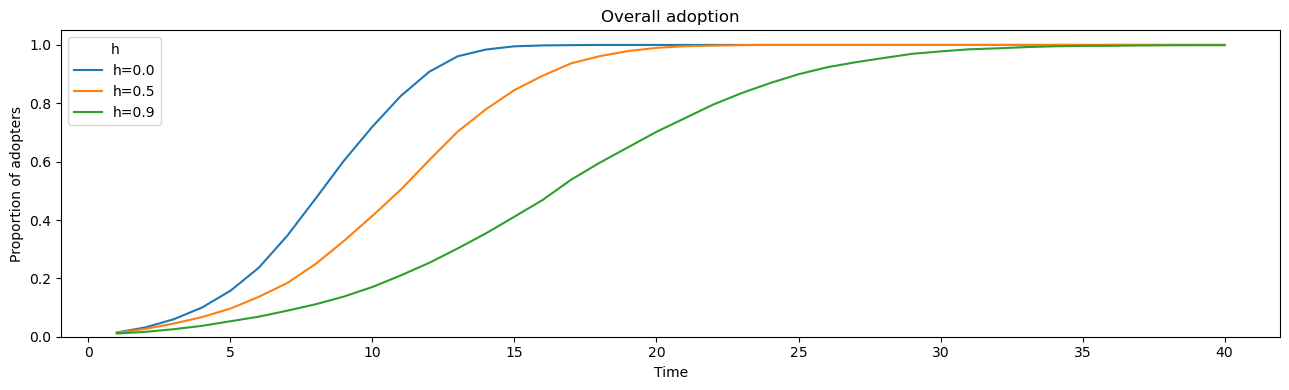

In [5]:
G      = nx.watts_strogatz_graph(n=200, k=6, p=0.1, seed=42)
h_vals = [0, 0.5, 0.9]
n_reps = 20

np.random.seed(7)
results = pd.concat([
    diffusion_homophily(G=G, p_t=0.3, h=h, r_max=40, sim=i).assign(h=h)
    for h in h_vals
    for i in range(n_reps)
], ignore_index=True)

mean_r = results.groupby(["h", "time"])["proportion"].mean().reset_index()

fig, axes = plt.subplots(figsize=(13, 4))

# Left: overall adoption by h
for h, grp in mean_r.groupby("h"):
    axes.plot(grp["time"], grp["proportion"], label=f"h={h}")
axes.set_ylim(0, 1.05)
axes.set_xlabel("Time")
axes.set_ylabel("Proportion of adopters")
axes.set_title("Overall adoption")
axes.legend(title="h")

plt.tight_layout()
plt.show()

# 3.

Test this model with different layout of network (at least 2 others).

What do you observe ? Does it make a difference ?

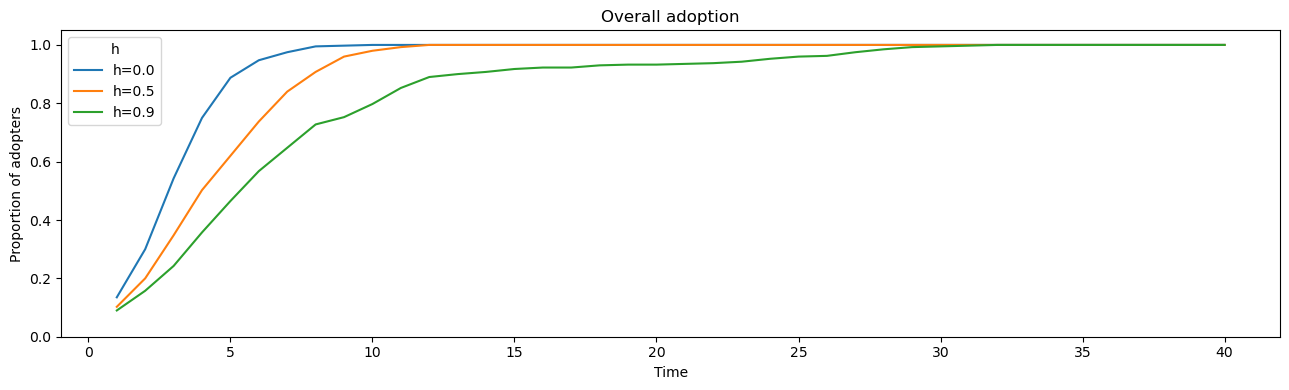

In [ ]:
G      = nx.watts_strogatz_graph(n=200, k=6, p=0.1, seed=42)
h_vals = [0, 0.5, 0.9]
n_reps = 20

np.random.seed(7)
results = pd.concat([
    diffusion_homophily(G=G, p_t=0.3, h=h, r_max=40, sim=i).assign(h=h)
    for h in h_vals
    for i in range(n_reps)
], ignore_index=True)

mean_r = results.groupby(["h", "time"])["proportion"].mean().reset_index()

fig, axes = plt.subplots(figsize=(13, 4))

# Left: overall adoption by h
for h, grp in mean_r.groupby("h"):
    axes.plot(grp["time"], grp["proportion"], label=f"h={h}")
axes.set_ylim(0, 1.05)
axes.set_xlabel("Time")
axes.set_ylabel("Proportion of adopters")
axes.set_title("Overall adoption")
axes.legend(title="h")

plt.tight_layout()
plt.show()